In [278]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [279]:
titanic_df = pd.read_csv("Titanic-Dataset.csv")
age_mean = int(titanic_df["Age"].mean())


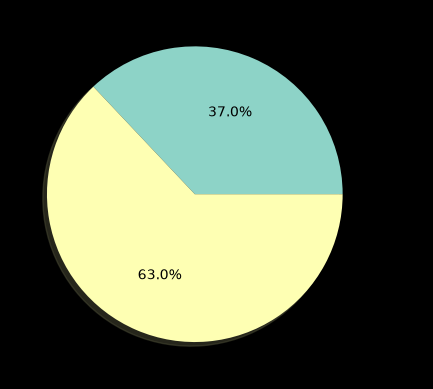

In [280]:
condition1 = np.logical_and(titanic_df["Pclass"] == 1, titanic_df["Survived"] == 1)
general_condition = np.logical_or(titanic_df["Age"] < 18, titanic_df["Sex"] == "female")
condition3 = np.logical_and(titanic_df["Pclass"] == 3, titanic_df["Survived"] == 1)

class_1 = titanic_df[titanic_df["Pclass"] == 1]
survivors_1_class = titanic_df[condition1]
sizes1 = [len(class_1.index) - len(survivors_1_class.index),len(survivors_1_class.index)]

class_3 = titanic_df[titanic_df["Pclass"] == 3]
survivors_3_class = titanic_df[condition3]



plt.pie(sizes1,labels=["1st class tickets owners","Survivers"],autopct='%1.1f%%', shadow=True, textprops={'color': 'black'})
plt.show()



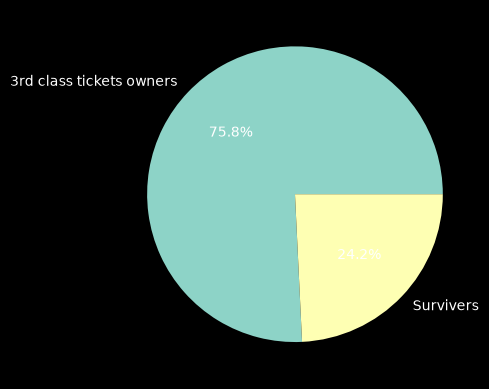

In [281]:
sizes3 = [len(class_3.index) - len(survivors_3_class.index),len(survivors_3_class.index)]
plt.pie(sizes3,labels=["3rd class tickets owners","Survivers"],autopct='%1.1f%%')
plt.show()


/var/folders/vx/1493k3cn7hz7zslsp9z6t1z00000gn/T/ipykernel_54971/2248814882.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  survivors_1_class_women = survivors_1_class[general_condition]


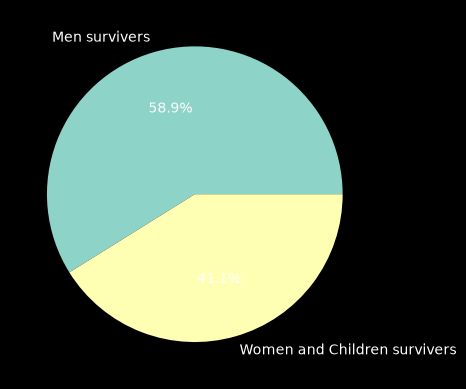

In [282]:
survivors_1_class_men = survivors_1_class["Sex"]=="male"
survivors_1_class_women = survivors_1_class[general_condition]
ratio1 = [len(survivors_1_class_men.index), len(survivors_1_class_women.index)]
plt.pie(ratio1,labels=["Men survivers", "Women and Children survivers"],autopct='%1.1f%%')
plt.show()





/var/folders/vx/1493k3cn7hz7zslsp9z6t1z00000gn/T/ipykernel_54971/3156013969.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  survivors_3_class_women = survivors_3_class[general_condition]


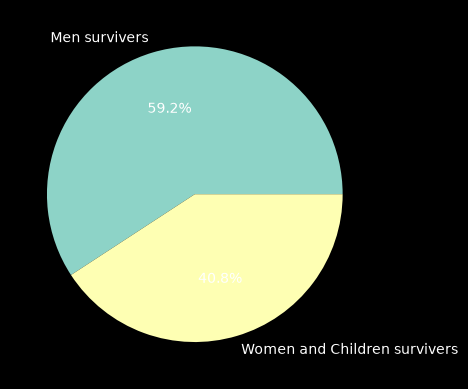

In [283]:
survivors_3_class_men = survivors_3_class["Sex"]=="male"
survivors_3_class_women = survivors_3_class[general_condition]
ratio2 = [len(survivors_3_class_men.index), len(survivors_3_class_women.index)]

plt.pie(ratio2,labels=["Men survivers", "Women and Children survivers"],autopct='%1.1f%%')
plt.show()


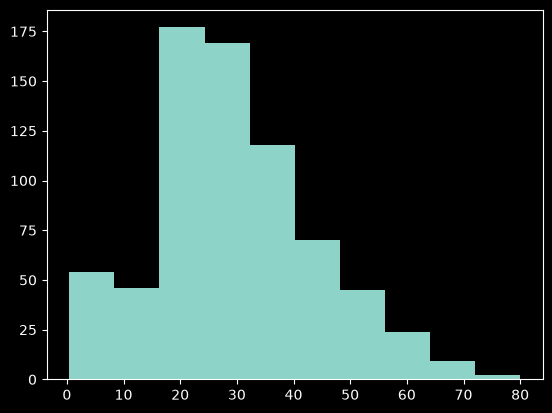

In [284]:
plt.hist(titanic_df["Age"])
plt.show()

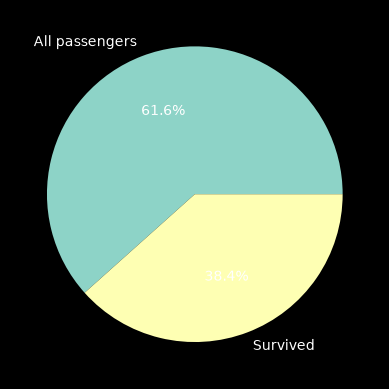

In [285]:
all_class_survivors = titanic_df[titanic_df["Survived"] == 1]
ratio_total = [len(titanic_df.index) - len(all_class_survivors.index), len(all_class_survivors.index)]
plt.pie(ratio_total,labels=["All passengers","Survived"],autopct='%1.1f%%')
plt.show()

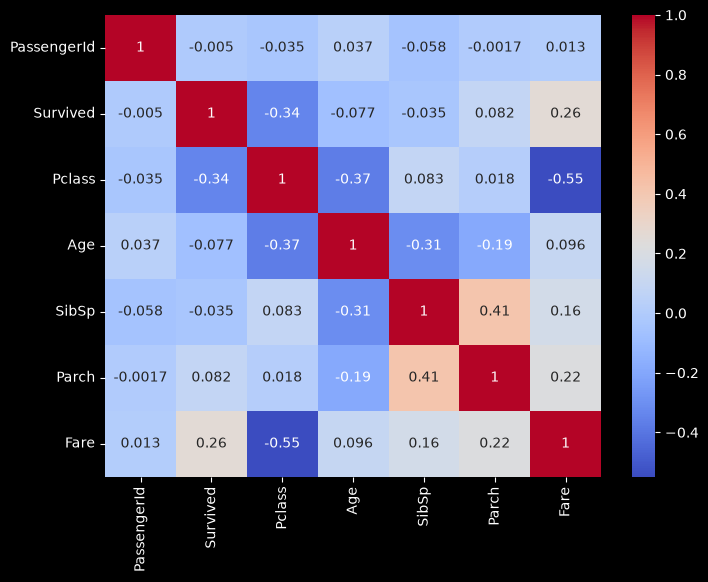

In [286]:
import seaborn as sns

corr = titanic_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [287]:
titanic_df["Sex"] = titanic_df["Sex"].replace({"male": 0, "female": 1})

Age_class1_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 1].mean())
Age_class2_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 2].mean())
Age_class3_mean = int(titanic_df["Age"][titanic_df["Pclass"] == 3].mean())

titanic_df.loc[titanic_df["Pclass"] == 1, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 1, "Age"].fillna(Age_class1_mean)
titanic_df.loc[titanic_df["Pclass"] == 2, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 2, "Age"].fillna(Age_class2_mean)
titanic_df.loc[titanic_df["Pclass"] == 3, "Age"] = titanic_df.loc[titanic_df["Pclass"] == 3, "Age"].fillna(Age_class3_mean)







In [288]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

In [289]:
model1 = RandomForestClassifier(random_state=64)
features = ["Pclass","Age","Sex", "Fare", "Parch","SibSp"]
X = titanic_df[features]
y = titanic_df["Survived"]
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=64)
model1.fit(train_X, train_y)
y_pred = model1.predict(test_X)

y_proba = model1.predict_proba(test_X)[:, 1]
model1_score = roc_auc_score(test_y, y_proba)







In [290]:
model2 = LogisticRegression(solver="lbfgs", C=1.0)
model2.fit(train_X,train_y)
y2_pred = model2.predict(test_X)
y2_proba = model2.predict_proba(test_X)[:, 1]
model2_score = roc_auc_score(test_y, y2_proba)


In [291]:
model_final = model1
if model2_score > model1_score:
    model_final = model2

In [292]:
titanic_df_test = pd.read_csv("test.csv")
titanic_df_test.loc[titanic_df_test["Pclass"] == 1, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 1, "Age"].fillna(Age_class1_mean)
titanic_df_test.loc[titanic_df_test["Pclass"] == 2, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 2, "Age"].fillna(Age_class2_mean)
titanic_df_test.loc[titanic_df_test["Pclass"] == 3, "Age"] = titanic_df_test.loc[titanic_df_test["Pclass"] == 3, "Age"].fillna(Age_class3_mean)
titanic_df_test["Sex"] = titanic_df_test["Sex"].replace({"male": 0, "female": 1})

titanic_df_test["Fare"] = titanic_df_test["Fare"].fillna(titanic_df["Fare"].mean())


In [293]:
X_final = titanic_df_test[features]
y_pred_final = model_final.predict(X_final)
#roc_auc_score(test_y, y_pred_final)

output = pd.DataFrame({'PassengerId': titanic_df_test.PassengerId,
                       'Survived': y_pred_final})
output.to_csv('submission_final_newww2.csv', index=False)
